In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)

import joblib

In [2]:
from xgboost import XGBClassifier

In [3]:
fraud = pd.read_csv("../data/processed/fraud_processed.csv")

credit = pd.read_csv("../data/processed/creditcard_processed.csv")

In [4]:
X_fraud = fraud.drop("class", axis=1)

y_fraud = fraud["class"]

In [5]:
X_credit = credit.drop("Class", axis=1)

y_credit = credit["Class"]

In [6]:

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (187004, 202)
X_test: (25830, 202)
y_train: (187004, 1)
y_test: (25830, 1)


In [8]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [9]:
print(type(y_train))

<class 'pandas.Series'>


In [11]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


Training class distribution:
class
0    93502
1    93502
Name: count, dtype: int64

Testing class distribution:
class
0    23376
1     2454
Name: count, dtype: int64


In [48]:
print(y_train.value_counts())

class
0    93502
1    93502
Name: count, dtype: int64


In [49]:
print(y_test.value_counts())

class
0    23376
1     2454
Name: count, dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [13]:
lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:, 1]

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    average_precision_score
)

import matplotlib.pyplot as plt

In [15]:
lr_f1 = f1_score(y_test, lr_pred)

print("F1 Score:", lr_f1)

F1 Score: 0.19733407904548844


In [16]:
lr_ap = average_precision_score(y_test, lr_prob)

print("Average Precision:", lr_ap)

Average Precision: 0.18023538002038927


In [17]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.95      0.28      0.43     23376
           1       0.11      0.86      0.20      2454

    accuracy                           0.33     25830
   macro avg       0.53      0.57      0.31     25830
weighted avg       0.87      0.33      0.41     25830



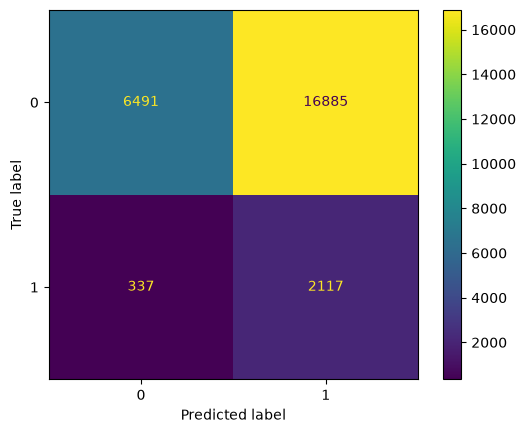

In [18]:
cm = confusion_matrix(y_test, lr_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.show()

In [50]:
confusion_matrix(y_test, lr_pred)

array([[ 6491, 16885],
       [  337,  2117]])

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [20]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:, 1]

In [21]:
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest F1:", rf_f1)

Random Forest F1: 0.6996904024767802


In [22]:
rf_ap = average_precision_score(y_test, rf_prob)

print("Random Forest Average Precision:", rf_ap)

Random Forest Average Precision: 0.6434063215093223


In [23]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     23376
           1       0.95      0.55      0.70      2454

    accuracy                           0.95     25830
   macro avg       0.95      0.77      0.84     25830
weighted avg       0.95      0.95      0.95     25830



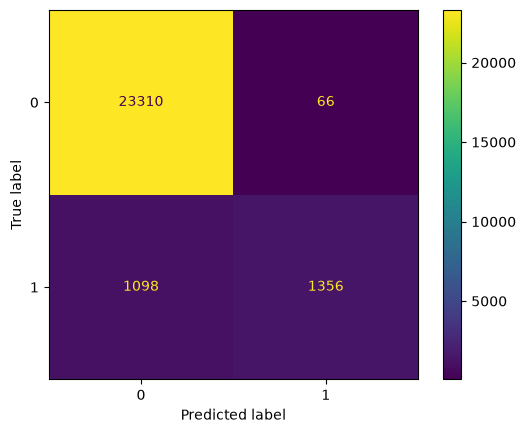

In [24]:
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.show()

In [25]:
from sklearn.model_selection import GridSearchCV

In [30]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, None]
}

In [31]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [32]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [20, None], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a c

In [33]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 200}


In [34]:
best_rf = grid_search.best_estimator_

In [35]:
best_pred = best_rf.predict(X_test)

best_prob = best_rf.predict_proba(X_test)[:, 1]

In [36]:
best_f1 = f1_score(y_test, best_pred)

print("Best F1 Score:", best_f1)

Best F1 Score: 0.6982980917998969


In [37]:
best_ap = average_precision_score(y_test, best_prob)

print("Best Average Precision:", best_ap)

Best Average Precision: 0.6447206402698143


In [38]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23376
           1       0.95      0.55      0.70      2454

    accuracy                           0.95     25830
   macro avg       0.95      0.77      0.84     25830
weighted avg       0.95      0.95      0.95     25830



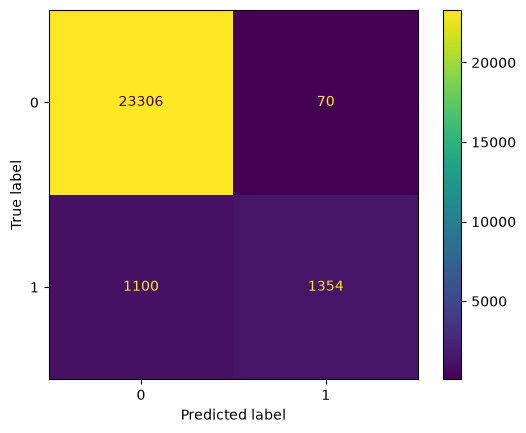

In [39]:
cm = confusion_matrix(y_test, best_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.show()

In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

In [41]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [43]:
cv_results = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=skf,
    scoring=["f1", "average_precision"],
    n_jobs=-1
)

In [44]:
print("Mean F1:", cv_results["test_f1"].mean())
print("Std F1:", cv_results["test_f1"].std())

print("Mean Average Precision:", cv_results["test_average_precision"].mean())
print("Std Average Precision:", cv_results["test_average_precision"].std())

Mean F1: 0.9683596712756326
Std F1: 0.0006355884832872736
Mean Average Precision: 0.9918077035830623
Std Average Precision: 0.00012757135401695097


In [45]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        best_f1
    ],
    "Average Precision": [
        lr_ap,
        rf_ap,
        best_ap
    ]
})

comparison

,Model,F1 Score,Average Precision
0,Logistic Regression,0.197334,0.180235
1,Random Forest,0.699690,0.643406
2,Tuned Random Forest,0.698298,0.644721


In [46]:
comparison = comparison.round(4)
comparison

,Model,F1 Score,Average Precision
0,Logistic Regression,0.1973,0.1802
1,Random Forest,0.6997,0.6434
2,Tuned Random Forest,0.6983,0.6447


In [47]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(best_rf, "../models/best_fraud_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!
